In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
import sys
import importlib
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
import config
importlib.reload(config)

print(f"Using device: {config.DEVICE}")

Using device: cuda


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

class VariantDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class VariantMLP(nn.Module):
    def __init__(self, input_dim=8, hidden_dims=[64, 32], dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1)
        )
    def forward(self, x): return self.network(x).squeeze(1)

class EnrichedMLP(nn.Module):
    def __init__(self, input_dim=84, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], hidden_dims[2]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[2], 1)
        )
    def forward(self, x): return self.network(x).squeeze(1)

class VariantCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=8, padding='same'), nn.ReLU(), nn.Dropout(dropout),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=8, padding='same'), nn.ReLU(), nn.Dropout(dropout),
            nn.MaxPool1d(2),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x).squeeze(1)

print("Model classes defined.")

Model classes defined.


In [5]:
# Load all three models
baseline_model = VariantMLP().to(config.DEVICE)
baseline_model.load_state_dict(torch.load(
    config.OUTPUTS_DIR / "mlp_baseline.pt", map_location=config.DEVICE
))
baseline_model.eval()

enriched_model = EnrichedMLP().to(config.DEVICE)
enriched_model.load_state_dict(torch.load(
    config.OUTPUTS_DIR / "mlp_enriched.pt", map_location=config.DEVICE
))
enriched_model.eval()

cnn_model = VariantCNN().to(config.DEVICE)
cnn_model.load_state_dict(torch.load(
    config.OUTPUTS_DIR / "cnn_best.pt", map_location=config.DEVICE
))
cnn_model.eval()

print("All three models loaded successfully.")

All three models loaded successfully.


In [6]:
# Load test sets
X_test_base = np.load(config.PROCESSED_DIR / "X_test.npy")
y_test_base = np.load(config.PROCESSED_DIR / "y_test.npy")

X_seq = np.load(config.PROCESSED_DIR / "X_seq.npy")
y_seq = np.load(config.PROCESSED_DIR / "y_seq.npy")

# Rebuild enriched test set
df = pd.read_csv(
    config.PROCESSED_DIR / "clinvar_filtered.tsv.gz",
    sep='\t', low_memory=False
)
df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)

NUCLEOTIDES = ['A', 'C', 'G', 'T']
TOP_N_GENES = 50
CHROMOSOMES = ['1','2','3','4','5','6','7','8','9','10',
               '11','12','13','14','15','16','17','18','19','20',
               '21','22','X','Y','MT']
top_genes = df_snv['GeneSymbol'].value_counts().head(TOP_N_GENES).index.tolist()
gene_to_idx = {gene: i for i, gene in enumerate(top_genes)}
chrom_to_idx = {c: i for i, c in enumerate(CHROMOSOMES)}

def one_hot_encode(base):
    vector = [0, 0, 0, 0]
    if base in NUCLEOTIDES:
        vector[NUCLEOTIDES.index(base)] = 1
    return vector

def encode_enriched(ref, alt, gene, chrom):
    allele = one_hot_encode(ref) + one_hot_encode(alt)
    gene_vec = [0] * (TOP_N_GENES + 1)
    gene_vec[gene_to_idx.get(gene, TOP_N_GENES)] = 1
    chrom_vec = [0] * len(CHROMOSOMES)
    chrom_vec[chrom_to_idx.get(str(chrom), 0)] = 1
    return allele + gene_vec + chrom_vec

print("Encoding enriched features...")
X_enriched = np.array([
    encode_enriched(ref, alt, gene, chrom)
    for ref, alt, gene, chrom in zip(
        df_snv['ReferenceAlleleVCF'],
        df_snv['AlternateAlleleVCF'],
        df_snv['GeneSymbol'],
        df_snv['Chromosome']
    )
])
y_enriched = df_snv['Label'].values

# Splits — same seed as training
_, X_te_en, _, y_te_en = train_test_split(
    X_enriched, y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)

_, X_te_seq, _, y_te_seq = train_test_split(
    X_seq, y_seq,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_seq
)

print(f"Baseline test:  {X_test_base.shape}")
print(f"Enriched test:  {X_te_en.shape}")
print(f"Sequence test:  {X_te_seq.shape}")

Encoding enriched features...
Baseline test:  (68365, 8)
Enriched test:  (68365, 84)
Sequence test:  (68365, 101, 4)


In [7]:
def get_predictions(model, X, dataset_class, device, batch_size=256):
    """Get probability predictions from a model on a numpy array."""
    dataset = dataset_class(X, np.zeros(len(X)))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    all_preds = []
    model.eval()
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
    return np.array(all_preds)

# Get predictions from all three models
print("Getting predictions...")
preds_baseline = get_predictions(baseline_model, X_test_base, VariantDataset, config.DEVICE)
preds_enriched = get_predictions(enriched_model, X_te_en,    VariantDataset, config.DEVICE)
preds_cnn      = get_predictions(cnn_model,      X_te_seq,   SeqDataset,     config.DEVICE)

# Labels — all three test sets have same labels
y_test = y_test_base

print(f"Baseline AUC: {roc_auc_score(y_test, preds_baseline):.4f}")
print(f"Enriched AUC: {roc_auc_score(y_test, preds_enriched):.4f}")
print(f"CNN AUC:      {roc_auc_score(y_te_seq, preds_cnn):.4f}")

Getting predictions...


D:\projects\claude_code\dissertation\clinvar\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv1d(


Baseline AUC: 0.5947
Enriched AUC: 0.6695
CNN AUC:      0.7289


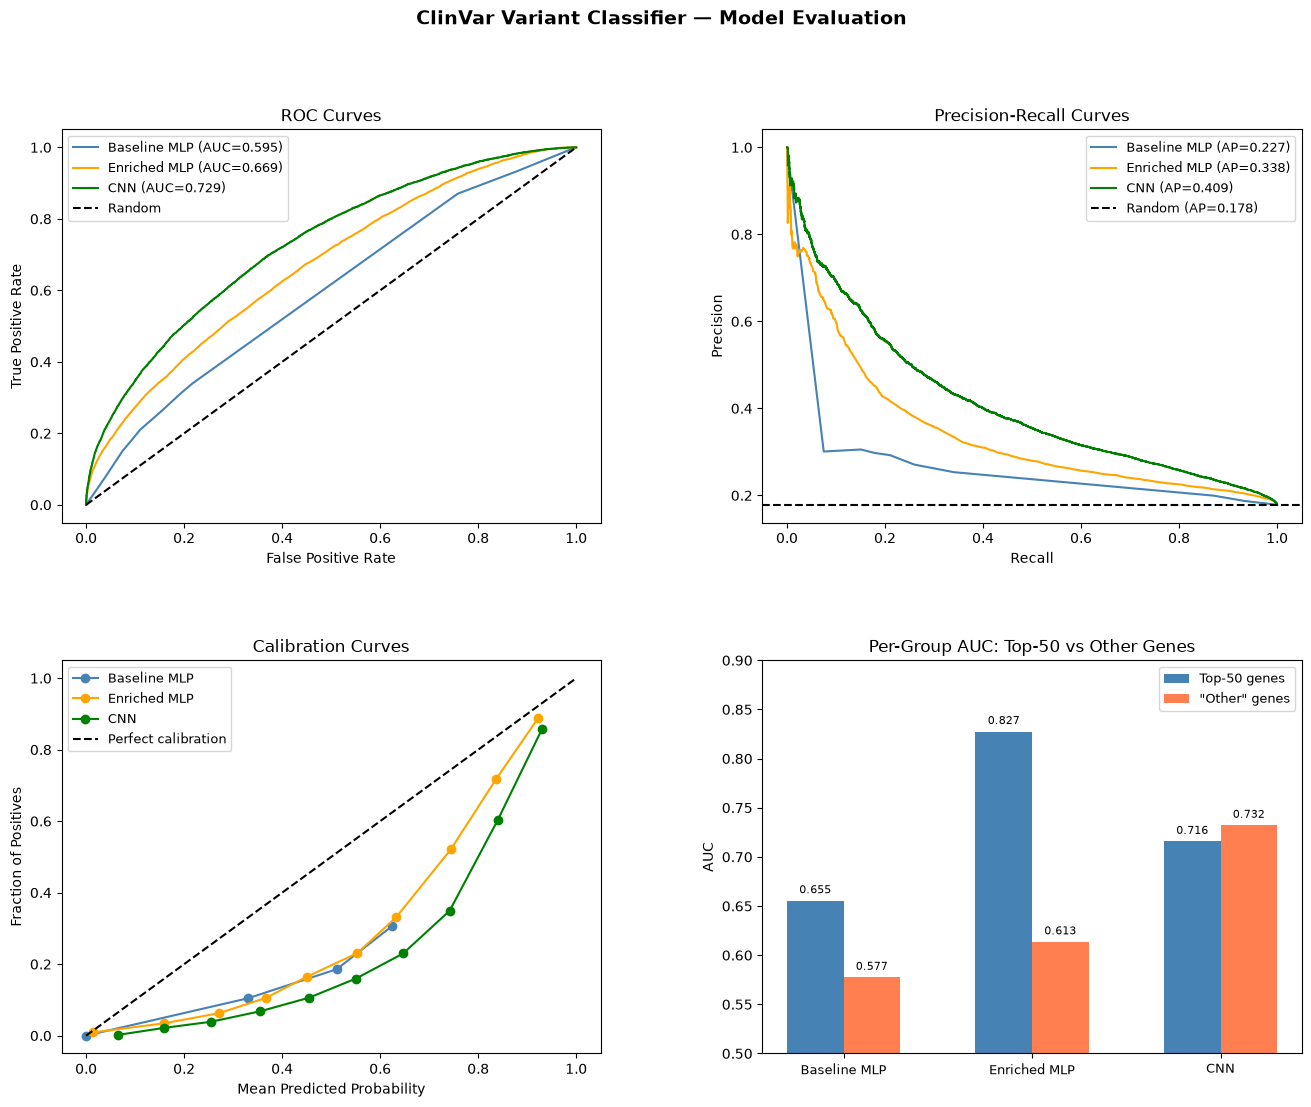

Saved.


In [8]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

models = {
    'Baseline MLP': (y_test,    preds_baseline, 'steelblue'),
    'Enriched MLP': (y_test,    preds_enriched, 'orange'),
    'CNN':          (y_te_seq,  preds_cnn,      'green'),
}

# ── 1. ROC Curves ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, (y, preds, colour) in models.items():
    fpr, tpr, _ = roc_curve(y, preds)
    auc = roc_auc_score(y, preds)
    ax1.plot(fpr, tpr, color=colour, label=f"{name} (AUC={auc:.3f})")
ax1.plot([0,1],[0,1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(fontsize=9)

# ── 2. Precision-Recall Curves ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, (y, preds, colour) in models.items():
    prec, rec, _ = precision_recall_curve(y, preds)
    ap = average_precision_score(y, preds)
    ax2.plot(rec, prec, color=colour, label=f"{name} (AP={ap:.3f})")
baseline_pr = y_test.mean()
ax2.axhline(y=baseline_pr, color='k', linestyle='--', label=f'Random (AP={baseline_pr:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(fontsize=9)

# ── 3. Calibration Curves ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for name, (y, preds, colour) in models.items():
    fraction_pos, mean_pred = calibration_curve(y, preds, n_bins=10)
    ax3.plot(mean_pred, fraction_pos, color=colour, marker='o', label=name)
ax3.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curves')
ax3.legend(fontsize=9)

# ── 4. Per-group AUC bar chart ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

# Get gene labels for test set
test_genes = df_snv['GeneSymbol'].values
_, te_idx, _, _ = train_test_split(
    np.arange(len(y_enriched)), y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)
test_gene_labels = test_genes[te_idx]
top50_mask = np.array([g in top_genes for g in test_gene_labels])
other_mask  = ~top50_mask

group_results = {}
for name, (y, preds, colour) in models.items():
    auc_top50 = roc_auc_score(y[top50_mask], preds[top50_mask])
    auc_other = roc_auc_score(y[other_mask], preds[other_mask])
    group_results[name] = (auc_top50, auc_other, colour)

x = np.arange(3)
width = 0.3
names = list(group_results.keys())
top50_aucs = [group_results[n][0] for n in names]
other_aucs = [group_results[n][1] for n in names]

bars1 = ax4.bar(x - width/2, top50_aucs, width, label='Top-50 genes', color='steelblue')
bars2 = ax4.bar(x + width/2, other_aucs, width, label='"Other" genes', color='coral')
ax4.set_xticks(x)
ax4.set_xticklabels(names, fontsize=9)
ax4.set_ylabel('AUC')
ax4.set_title('Per-Group AUC: Top-50 vs Other Genes')
ax4.legend(fontsize=9)
ax4.set_ylim(0.5, 0.9)
for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('ClinVar Variant Classifier — Model Evaluation', fontsize=14, fontweight='bold')
fig.savefig(config.FIGURES_DIR / "evaluation_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

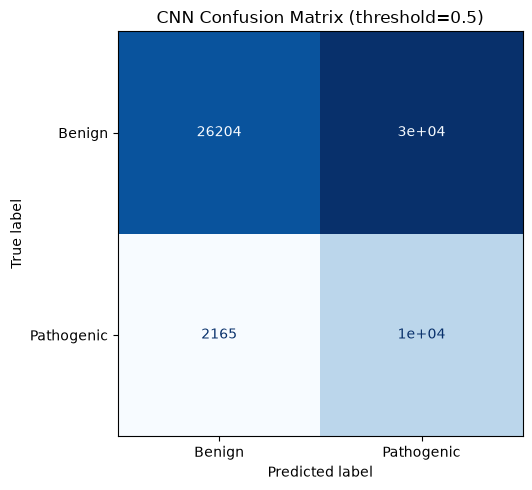

Saved.


In [9]:
# Confusion matrix for CNN at threshold 0.5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.5
y_pred_cnn = (preds_cnn >= threshold).astype(int)

cm = confusion_matrix(y_te_seq, y_pred_cnn)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Pathogenic']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CNN Confusion Matrix (threshold={threshold})')

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "cnn_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")